In [1]:
%load_ext autoreload
%autoreload 2

In [20]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from simulation import GridWorldEnv, CreateGrid
from algorithm import QLearning, SASAR
from helper import Metrics, get_grid, get_grid_img, create_show_grid

# Intelligente Robotik 
#### WS 2024/25
Julienne Eder, Lea Achter

---

## Dynamische Erstellung der Grid Worlds

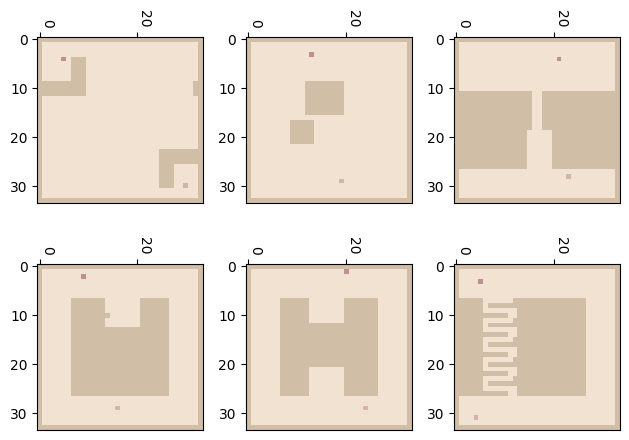

In [3]:
fig, axes = plt.subplots(nrows=2, ncols=3)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

grid_creator = CreateGrid()

star_dict = grid_creator.create_grid('star_grid', 32)
star_data = get_grid_img(star_dict['grid'], (star_dict['agent_x'], star_dict['agent_y']), (star_dict['goal_x'],star_dict['goal_y']))
im = get_grid(star_data, ax=ax1)

simple__dict = grid_creator.create_grid('simple_grid', 32)
simple_data = get_grid_img(simple__dict['grid'], (simple__dict['agent_x'], simple__dict['agent_y']), (simple__dict['goal_x'] ,simple__dict['goal_y']))
im = get_grid(simple_data, ax=ax2)

bottleneck_dict = grid_creator.create_grid('bottleneck_grid', 32)
bottleneck_data = get_grid_img(bottleneck_dict['grid'], (bottleneck_dict['agent_x'], bottleneck_dict['agent_y']), (bottleneck_dict['goal_x'],bottleneck_dict['goal_y']))
im = get_grid(bottleneck_data, ax=ax3)

trap_dict = grid_creator.create_grid('trap_grid', 32)
trap_data = get_grid_img(trap_dict['grid'], (trap_dict['agent_x'], trap_dict['agent_y']), (trap_dict['goal_x'],trap_dict['goal_y']))
im = get_grid(trap_data, ax=ax4)

doubletrap_dict = grid_creator.create_grid('doubletrap_grid', 32)
doubletrap_data = get_grid_img(doubletrap_dict['grid'], (doubletrap_dict['agent_x'], doubletrap_dict['agent_y']), (doubletrap_dict['goal_x'],doubletrap_dict['goal_y']))
im = get_grid(doubletrap_data, ax=ax5)

detour_dict = grid_creator.create_grid('detour_grid', 32)
detour_data = get_grid_img(detour_dict['grid'], (detour_dict['agent_x'], detour_dict['agent_y']), (detour_dict['goal_x'],detour_dict['goal_y']))
im = get_grid(detour_data, ax=ax6)

fig.tight_layout()
plt.show()


Grids können durch einen Größenparameter dynamisch angepasst werden. Allgemein herrschen folgende Bedingungen:

- 2D-Umwelt
- statische Umgebung 
- Hindernisse sind a priori bekannt
- Umgebung: ein Roboter
- mobiler Roboter
- Objektform fest
- Hindernisse durch Roboter nicht bewegbar
- Roboterbewegung eingeschränkt (4 Himmelsrichtungen)
- Grids ändern den Standort des Agenten und Zielpunktes bzw. den Standort der Hindernisse

## Algorithmen

| |  A* (manhattan) | Wavefront (BFS)  | MITM (BFS) | Q-Learning| SASAR|
|:------------- |:------------- |:---------------:| -------------:| -------------:|-------------:|
| Speicherkomplexität | O(n)         | O(rows * cols)|O(rows * cols)|O(n_states * action_space)| O(n_states * action_space)| 
| Laufzeitkomplexität | O(n^2 log n)  |O(rows * cols)|O(rows * cols)| O(episodes * max_steps * action_space)| O(episodes * max_steps * action_space)| 
| Echtzeit (E) / Anytime (A)| E   | E | E | A | A | 
| Ausführungszeit (avg_empty_64) | 0.05538 ± 0.04596 | 0.00508 ± 0.00033 | 0.00395 ± 0.00090 | - |  -| 
| Steps bis Konvergenz (avg_empty_64)| 1752.20000 ± 983.96553   | 3197.20000 ± 225.06035   | 2306.20000 ± 297.81095 | - | - | 
| Durchschnittliche Pfadlänge (avg_empty_64)| 65.40000 ± 7.88923 |    63.00000 ± 6.78233    |63.20000 ± 6.91086| - | -| 


\
\
Meet-in-the-middle (MITM) \
breadth-first search (BFS) 

### A* Algorithmus

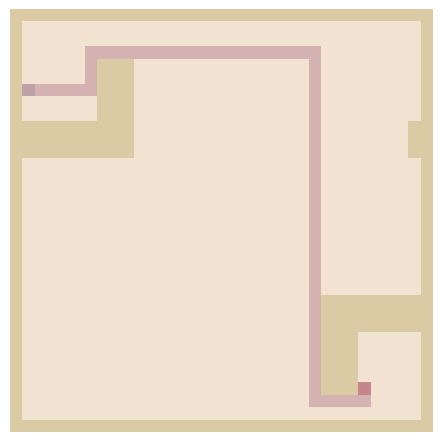

In [4]:
# show example grid

data = create_show_grid(algorithm='A-star', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [5]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df_astar_16 = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_astar_16



Metriken des A*-Algorithmus mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00035 ± 0.00015,16.80000 ± 0.74833,134.00000 ± 76.58982,13.75972 ± 0.19613
1,star_grid,0.00214 ± 0.00038,31.40000 ± 0.80000,876.00000 ± 294.15642,13.84291 ± 0.03509
2,simple_grid,0.00035 ± 0.00016,17.60000 ± 1.49666,1485.00000 ± 82.72122,13.15874 ± 0.60714
3,bottleneck_grid,0.00012 ± 0.00004,18.00000 ± 1.54919,1694.00000 ± 59.25875,10.55089 ± 0.16654
4,trap_grid,0.00029 ± 0.00012,21.40000 ± 2.65330,1972.60000 ± 83.54783,11.32370 ± 0.08932
5,doubletrap_grid,0.00028 ± 0.00017,22.60000 ± 2.05913,2228.40000 ± 83.58612,11.75757 ± 0.24284
6,detour_grid,0.00010 ± 0.00002,19.00000 ± 0.63246,2424.80000 ± 39.03537,11.35649 ± 0.07869
7,all,0.00052 ± 0.00069,20.97143 ± 4.93666,1544.97143 ± 756.53792,12.25000 ± 1.25000


In [6]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df_astar_32 = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_astar_32



Metriken des A*-Algorithmus mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00206 ± 0.00275,32.00000 ± 5.51362,278.00000 ± 243.68750,26.49268 ± 0.28271
1,star_grid,0.02168 ± 0.00204,60.80000 ± 1.60000,2910.80000 ± 1040.24293,25.84905 ± 0.06149
2,simple_grid,0.00183 ± 0.00069,33.00000 ± 2.75681,4875.40000 ± 214.32461,23.32267 ± 1.45682
3,bottleneck_grid,0.00117 ± 0.00041,36.20000 ± 3.70945,5614.80000 ± 191.26359,19.18729 ± 0.60281
4,trap_grid,0.00121 ± 0.00065,38.60000 ± 4.22374,6234.20000 ± 236.02830,20.67764 ± 0.29019
5,doubletrap_grid,0.00229 ± 0.00151,43.80000 ± 3.31059,7208.40000 ± 309.34356,20.85278 ± 0.21887
6,detour_grid,0.00497 ± 0.00060,74.80000 ± 2.31517,8660.80000 ± 497.81177,21.34909 ± 0.14798
7,all,0.00503 ± 0.00706,45.60000 ± 15.38311,5111.77143 ± 2629.31433,22.53303 ± 2.64260


In [7]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df_astar_64 = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_astar_64



Metriken des A*-Algorithmus mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.03455 ± 0.02698,69.00000 ± 9.33809,2431.60000 ± 982.47394,52.02500 ± 1.08587
1,star_grid,0.23436 ± 0.02460,110.00000 ± 5.17687,11529.40000 ± 3576.54736,48.95197 ± 0.62068
2,simple_grid,0.03475 ± 0.01826,75.60000 ± 4.58694,19583.00000 ± 1142.29541,38.50888 ± 1.90259
3,bottleneck_grid,0.01445 ± 0.00711,72.40000 ± 7.68375,22625.60000 ± 820.33227,38.06914 ± 1.48283
4,trap_grid,0.01419 ± 0.00837,80.00000 ± 11.24278,25507.80000 ± 826.58004,38.97630 ± 1.48833
5,doubletrap_grid,0.01121 ± 0.00838,76.40000 ± 7.03136,27748.80000 ± 748.41122,39.15940 ± 0.70399
6,detour_grid,0.04942 ± 0.01350,146.60000 ± 5.85150,32055.80000 ± 1695.94781,40.43172 ± 0.33973
7,all,0.05613 ± 0.07586,90.00000 ± 27.38821,20211.71429 ± 9582.20110,42.30320 ± 5.42095


### Wavefront

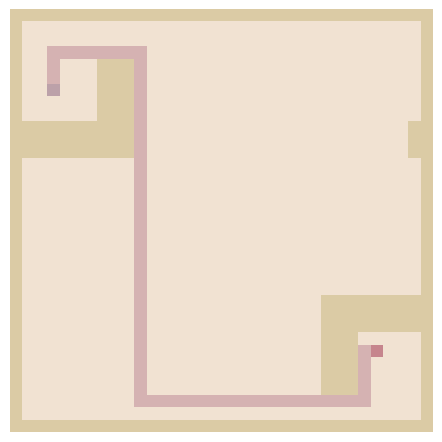

In [8]:
# show example grid

data = create_show_grid(algorithm='Wavefront', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [9]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df_wf_16 = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_wf_16



Metriken des Wavefront mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00017 ± 0.00003,17.00000 ± 2.36643,196.60000 ± 29.89716,13.47157 ± 0.17681
1,star_grid,0.00018 ± 0.00004,30.80000 ± 1.16619,234.00000 ± 0.00000,13.82466 ± 0.07421
2,simple_grid,0.00012 ± 0.00002,17.00000 ± 2.75681,175.80000 ± 33.81361,12.67541 ± 0.46014
3,bottleneck_grid,0.00007 ± 0.00000,17.60000 ± 1.62481,103.60000 ± 8.80000,10.30231 ± 0.10480
4,trap_grid,0.00009 ± 0.00001,21.00000 ± 1.67332,136.20000 ± 14.90503,11.39967 ± 0.14850
5,doubletrap_grid,0.00011 ± 0.00001,23.20000 ± 0.74833,150.00000 ± 9.89949,11.44406 ± 0.18234
6,detour_grid,0.00006 ± 0.00001,18.40000 ± 0.80000,90.40000 ± 6.01997,11.29597 ± 0.12658
7,all,0.00012 ± 0.00005,20.71429 ± 4.95449,155.22857 ± 50.80556,12.05909 ± 1.21330


In [10]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df_wf_32 = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_wf_32



Metriken des Wavefront mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00063 ± 0.00008,33.80000 ± 3.70945,842.40000 ± 76.53130,26.08044 ± 0.23528
1,star_grid,0.00068 ± 0.00004,58.00000 ± 1.78885,923.20000 ± 5.49181,25.78523 ± 0.01502
2,simple_grid,0.00055 ± 0.00005,33.40000 ± 1.20000,774.00000 ± 41.28922,22.72579 ± 1.05269
3,bottleneck_grid,0.00027 ± 0.00001,36.00000 ± 2.09762,402.40000 ± 17.52256,19.26168 ± 0.23729
4,trap_grid,0.00040 ± 0.00002,45.20000 ± 2.71293,614.60000 ± 27.66659,20.68411 ± 0.41341
5,doubletrap_grid,0.00047 ± 0.00009,46.00000 ± 1.41421,642.00000 ± 39.21734,21.24417 ± 0.55516
6,detour_grid,0.00038 ± 0.00001,74.20000 ± 2.71293,563.00000 ± 12.89961,22.11891 ± 0.44964
7,all,0.00048 ± 0.00014,46.65714 ± 14.06098,680.22857 ± 169.53568,22.55719 ± 2.42158


In [11]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df_wf_64 = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_wf_64



Metriken des Wavefront mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00236 ± 0.00023,66.20000 ± 5.74108,3216.20000 ± 307.38081,51.94531 ± 0.56064
1,star_grid,0.00255 ± 0.00003,113.20000 ± 8.13388,3645.00000 ± 30.69853,49.75118 ± 0.31506
2,simple_grid,0.00205 ± 0.00022,65.60000 ± 5.81722,2915.40000 ± 333.37822,39.30342 ± 3.59077
3,bottleneck_grid,0.00124 ± 0.00011,69.40000 ± 8.11419,1804.40000 ± 140.47434,36.85612 ± 0.59664
4,trap_grid,0.00168 ± 0.00011,88.40000 ± 5.00400,2497.60000 ± 115.64013,39.37897 ± 0.92583
5,doubletrap_grid,0.00156 ± 0.00025,79.40000 ± 10.59434,2304.80000 ± 377.14369,39.64750 ± 0.63359
6,detour_grid,0.00136 ± 0.00001,144.40000 ± 3.72022,2064.80000 ± 18.55155,41.71179 ± 0.26776
7,all,0.00183 ± 0.00049,89.51429 ± 28.14998,2635.45714 ± 650.46192,42.65633 ± 5.57015


### Meet-in-the-Middle

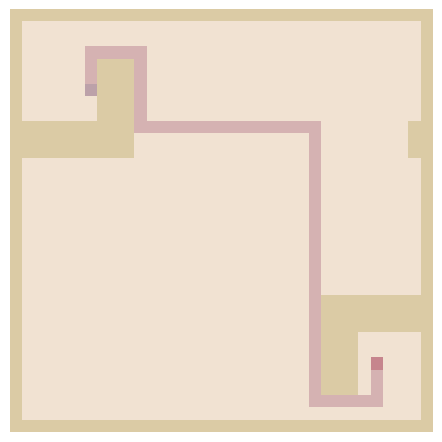

In [12]:
# show example grid

data = create_show_grid(algorithm='MITM', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [13]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df_mitm_16 = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_mitm_16



Metriken des MITM mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00012 ± 0.00005,18.60000 ± 1.20000,136.20000 ± 22.66627,13.49551 ± 0.12101
1,star_grid,0.00012 ± 0.00000,31.40000 ± 1.62481,168.00000 ± 0.00000,13.42692 ± 0.10613
2,simple_grid,0.00012 ± 0.00003,17.60000 ± 2.87054,132.80000 ± 32.03998,12.98068 ± 0.26550
3,bottleneck_grid,0.00008 ± 0.00000,20.00000 ± 1.09545,102.40000 ± 5.16140,10.37790 ± 0.06760
4,trap_grid,0.00008 ± 0.00001,19.80000 ± 1.72047,106.20000 ± 13.77534,11.31437 ± 0.08154
5,doubletrap_grid,0.00011 ± 0.00001,23.60000 ± 0.48990,149.00000 ± 11.45426,11.52041 ± 0.23690
6,detour_grid,0.00016 ± 0.00020,19.00000 ± 1.26491,67.20000 ± 1.60000,11.38519 ± 0.17279
7,all,0.00011 ± 0.00008,21.42857 ± 4.71645,123.11429 ± 35.21750,12.07157 ± 1.14026


In [14]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df_mitm_32 = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_mitm_32



Metriken des MITM mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00048 ± 0.00009,37.00000 ± 6.41872,643.40000 ± 165.38996,26.15517 ± 0.21206
1,star_grid,0.00046 ± 0.00001,60.60000 ± 1.74356,708.00000 ± 0.00000,25.17912 ± 0.13852
2,simple_grid,0.00034 ± 0.00005,32.60000 ± 4.58694,497.60000 ± 103.92228,22.39365 ± 1.08251
3,bottleneck_grid,0.00069 ± 0.00079,37.80000 ± 2.48193,436.80000 ± 19.13531,19.04522 ± 0.37332
4,trap_grid,0.00040 ± 0.00003,43.80000 ± 3.65513,507.80000 ± 62.89165,20.21440 ± 0.13978
5,doubletrap_grid,0.00033 ± 0.00003,38.60000 ± 3.13688,481.40000 ± 40.06295,20.79140 ± 0.42264
6,detour_grid,0.00035 ± 0.00000,75.60000 ± 1.20000,529.00000 ± 0.00000,21.40343 ± 0.08250
7,all,0.00044 ± 0.00032,46.57143 ± 14.97862,543.42857 ± 119.49496,22.16891 ± 2.46818


In [15]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df_mitm_64 = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_mitm_64



Metriken des MITM mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00199 ± 0.00101,65.20000 ± 8.42378,2211.40000 ± 374.51494,51.43734 ± 0.32067
1,star_grid,0.00211 ± 0.00015,116.60000 ± 5.16140,2988.80000 ± 15.79114,47.81739 ± 0.46570
2,simple_grid,0.00163 ± 0.00016,69.60000 ± 4.49889,2384.80000 ± 189.30335,40.34688 ± 3.54603
3,bottleneck_grid,0.00110 ± 0.00004,67.40000 ± 7.00286,1669.20000 ± 51.40973,35.95644 ± 0.59151
4,trap_grid,0.00131 ± 0.00018,83.60000 ± 11.11036,2004.00000 ± 273.67060,38.23104 ± 0.54907
5,doubletrap_grid,0.00156 ± 0.00005,85.00000 ± 4.47214,2366.60000 ± 72.72579,38.49660 ± 0.51848
6,detour_grid,0.00129 ± 0.00002,148.00000 ± 4.73286,1999.00000 ± 0.00000,40.53586 ± 0.26664
7,all,0.00157 ± 0.00053,90.77143 ± 29.29660,2231.97143 ± 430.41950,41.83165 ± 5.40466


#### Überblick Algorithmen

In [16]:
# avg_time
column_names = ['benchmark', 'astar_16', 'astar_32', 'astar_64', 
                'wavefront_16', 'wavefront_32', 'wavefront_64',
                'mitm_16', 'mitm_32', 'mitm_64']

df_avg_time = pd.concat([df_astar_16.iloc[:,:2], df_astar_32.iloc[:,1], df_astar_64.iloc[:,1], 
                         df_wf_16.iloc[:,1], df_wf_32.iloc[:,1], df_wf_64.iloc[:,1],
                         df_mitm_16.iloc[:,1], df_mitm_32.iloc[:,1], df_mitm_64.iloc[:,1]
                        ], axis=1)
df_avg_time.columns=column_names
print('\n\nDurchschnittliche Zeit die benötigt wurde um den Pfad zu finden:\n')
df_avg_time



Durchschnittliche Zeit die benötigt wurde um den Pfad zu finden:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,0.00035 ± 0.00015,0.00206 ± 0.00275,0.03455 ± 0.02698,0.00017 ± 0.00003,0.00063 ± 0.00008,0.00236 ± 0.00023,0.00012 ± 0.00005,0.00048 ± 0.00009,0.00199 ± 0.00101
1,star_grid,0.00214 ± 0.00038,0.02168 ± 0.00204,0.23436 ± 0.02460,0.00018 ± 0.00004,0.00068 ± 0.00004,0.00255 ± 0.00003,0.00012 ± 0.00000,0.00046 ± 0.00001,0.00211 ± 0.00015
2,simple_grid,0.00035 ± 0.00016,0.00183 ± 0.00069,0.03475 ± 0.01826,0.00012 ± 0.00002,0.00055 ± 0.00005,0.00205 ± 0.00022,0.00012 ± 0.00003,0.00034 ± 0.00005,0.00163 ± 0.00016
3,bottleneck_grid,0.00012 ± 0.00004,0.00117 ± 0.00041,0.01445 ± 0.00711,0.00007 ± 0.00000,0.00027 ± 0.00001,0.00124 ± 0.00011,0.00008 ± 0.00000,0.00069 ± 0.00079,0.00110 ± 0.00004
4,trap_grid,0.00029 ± 0.00012,0.00121 ± 0.00065,0.01419 ± 0.00837,0.00009 ± 0.00001,0.00040 ± 0.00002,0.00168 ± 0.00011,0.00008 ± 0.00001,0.00040 ± 0.00003,0.00131 ± 0.00018
5,doubletrap_grid,0.00028 ± 0.00017,0.00229 ± 0.00151,0.01121 ± 0.00838,0.00011 ± 0.00001,0.00047 ± 0.00009,0.00156 ± 0.00025,0.00011 ± 0.00001,0.00033 ± 0.00003,0.00156 ± 0.00005
6,detour_grid,0.00010 ± 0.00002,0.00497 ± 0.00060,0.04942 ± 0.01350,0.00006 ± 0.00001,0.00038 ± 0.00001,0.00136 ± 0.00001,0.00016 ± 0.00020,0.00035 ± 0.00000,0.00129 ± 0.00002
7,all,0.00052 ± 0.00069,0.00503 ± 0.00706,0.05613 ± 0.07586,0.00012 ± 0.00005,0.00048 ± 0.00014,0.00183 ± 0.00049,0.00011 ± 0.00008,0.00044 ± 0.00032,0.00157 ± 0.00053


In [17]:
# avg_path_length

df_avg_path = pd.concat([df_astar_16.iloc[:,0], df_astar_16.iloc[:,2], df_astar_32.iloc[:,2], df_astar_64.iloc[:,2], 
                         df_wf_16.iloc[:,2], df_wf_32.iloc[:,2], df_wf_64.iloc[:,2],
                         df_mitm_16.iloc[:,2], df_mitm_32.iloc[:,2], df_mitm_64.iloc[:,2]
                        ], axis=1)
df_avg_path.columns=column_names
print('\n\nDurchschnittliche Pfadlänge:\n')
df_avg_path



Durchschnittliche Pfadlänge:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,16.80000 ± 0.74833,32.00000 ± 5.51362,69.00000 ± 9.33809,17.00000 ± 2.36643,33.80000 ± 3.70945,66.20000 ± 5.74108,18.60000 ± 1.20000,37.00000 ± 6.41872,65.20000 ± 8.42378
1,star_grid,31.40000 ± 0.80000,60.80000 ± 1.60000,110.00000 ± 5.17687,30.80000 ± 1.16619,58.00000 ± 1.78885,113.20000 ± 8.13388,31.40000 ± 1.62481,60.60000 ± 1.74356,116.60000 ± 5.16140
2,simple_grid,17.60000 ± 1.49666,33.00000 ± 2.75681,75.60000 ± 4.58694,17.00000 ± 2.75681,33.40000 ± 1.20000,65.60000 ± 5.81722,17.60000 ± 2.87054,32.60000 ± 4.58694,69.60000 ± 4.49889
3,bottleneck_grid,18.00000 ± 1.54919,36.20000 ± 3.70945,72.40000 ± 7.68375,17.60000 ± 1.62481,36.00000 ± 2.09762,69.40000 ± 8.11419,20.00000 ± 1.09545,37.80000 ± 2.48193,67.40000 ± 7.00286
4,trap_grid,21.40000 ± 2.65330,38.60000 ± 4.22374,80.00000 ± 11.24278,21.00000 ± 1.67332,45.20000 ± 2.71293,88.40000 ± 5.00400,19.80000 ± 1.72047,43.80000 ± 3.65513,83.60000 ± 11.11036
5,doubletrap_grid,22.60000 ± 2.05913,43.80000 ± 3.31059,76.40000 ± 7.03136,23.20000 ± 0.74833,46.00000 ± 1.41421,79.40000 ± 10.59434,23.60000 ± 0.48990,38.60000 ± 3.13688,85.00000 ± 4.47214
6,detour_grid,19.00000 ± 0.63246,74.80000 ± 2.31517,146.60000 ± 5.85150,18.40000 ± 0.80000,74.20000 ± 2.71293,144.40000 ± 3.72022,19.00000 ± 1.26491,75.60000 ± 1.20000,148.00000 ± 4.73286
7,all,20.97143 ± 4.93666,45.60000 ± 15.38311,90.00000 ± 27.38821,20.71429 ± 4.95449,46.65714 ± 14.06098,89.51429 ± 28.14998,21.42857 ± 4.71645,46.57143 ± 14.97862,90.77143 ± 29.29660


In [18]:
# avg_steps_to_converge 	

df_avg_step = pd.concat([df_astar_16.iloc[:,0], df_astar_16.iloc[:,3], df_astar_32.iloc[:,3], df_astar_64.iloc[:,3], 
                         df_wf_16.iloc[:,3], df_wf_32.iloc[:,3], df_wf_64.iloc[:,3],
                         df_mitm_16.iloc[:,3], df_mitm_32.iloc[:,3], df_mitm_64.iloc[:,3]
                        ], axis=1)
df_avg_step.columns=column_names
print('\n\nDurchschnittliche Anzahl der Knoten die betrachtet werden müssen bis Konvergenz:\n')
df_avg_step



Durchschnittliche Anzahl der Knoten die betrachtet werden müssen bis Konvergenz:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,134.00000 ± 76.58982,278.00000 ± 243.68750,2431.60000 ± 982.47394,196.60000 ± 29.89716,842.40000 ± 76.53130,3216.20000 ± 307.38081,136.20000 ± 22.66627,643.40000 ± 165.38996,2211.40000 ± 374.51494
1,star_grid,876.00000 ± 294.15642,2910.80000 ± 1040.24293,11529.40000 ± 3576.54736,234.00000 ± 0.00000,923.20000 ± 5.49181,3645.00000 ± 30.69853,168.00000 ± 0.00000,708.00000 ± 0.00000,2988.80000 ± 15.79114
2,simple_grid,1485.00000 ± 82.72122,4875.40000 ± 214.32461,19583.00000 ± 1142.29541,175.80000 ± 33.81361,774.00000 ± 41.28922,2915.40000 ± 333.37822,132.80000 ± 32.03998,497.60000 ± 103.92228,2384.80000 ± 189.30335
3,bottleneck_grid,1694.00000 ± 59.25875,5614.80000 ± 191.26359,22625.60000 ± 820.33227,103.60000 ± 8.80000,402.40000 ± 17.52256,1804.40000 ± 140.47434,102.40000 ± 5.16140,436.80000 ± 19.13531,1669.20000 ± 51.40973
4,trap_grid,1972.60000 ± 83.54783,6234.20000 ± 236.02830,25507.80000 ± 826.58004,136.20000 ± 14.90503,614.60000 ± 27.66659,2497.60000 ± 115.64013,106.20000 ± 13.77534,507.80000 ± 62.89165,2004.00000 ± 273.67060
5,doubletrap_grid,2228.40000 ± 83.58612,7208.40000 ± 309.34356,27748.80000 ± 748.41122,150.00000 ± 9.89949,642.00000 ± 39.21734,2304.80000 ± 377.14369,149.00000 ± 11.45426,481.40000 ± 40.06295,2366.60000 ± 72.72579
6,detour_grid,2424.80000 ± 39.03537,8660.80000 ± 497.81177,32055.80000 ± 1695.94781,90.40000 ± 6.01997,563.00000 ± 12.89961,2064.80000 ± 18.55155,67.20000 ± 1.60000,529.00000 ± 0.00000,1999.00000 ± 0.00000
7,all,1544.97143 ± 756.53792,5111.77143 ± 2629.31433,20211.71429 ± 9582.20110,155.22857 ± 50.80556,680.22857 ± 169.53568,2635.45714 ± 650.46192,123.11429 ± 35.21750,543.42857 ± 119.49496,2231.97143 ± 430.41950


In [19]:
# avg_distance

df_avg_dist = pd.concat([df_astar_16.iloc[:,0], df_astar_16.iloc[:,4], df_astar_32.iloc[:,4], df_astar_64.iloc[:,4], 
                         df_wf_16.iloc[:,4], df_wf_32.iloc[:,4], df_wf_64.iloc[:,4],
                         df_mitm_16.iloc[:,4], df_mitm_32.iloc[:,4], df_mitm_64.iloc[:,4]
                        ], axis=1)
df_avg_dist.columns=column_names
print('\n\nDurchschnittliche Distanz zu Hindernissen:\n')
df_avg_dist



Durchschnittliche Distanz zu Hindernissen:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,13.75972 ± 0.19613,26.49268 ± 0.28271,52.02500 ± 1.08587,13.47157 ± 0.17681,26.08044 ± 0.23528,51.94531 ± 0.56064,13.49551 ± 0.12101,26.15517 ± 0.21206,51.43734 ± 0.32067
1,star_grid,13.84291 ± 0.03509,25.84905 ± 0.06149,48.95197 ± 0.62068,13.82466 ± 0.07421,25.78523 ± 0.01502,49.75118 ± 0.31506,13.42692 ± 0.10613,25.17912 ± 0.13852,47.81739 ± 0.46570
2,simple_grid,13.15874 ± 0.60714,23.32267 ± 1.45682,38.50888 ± 1.90259,12.67541 ± 0.46014,22.72579 ± 1.05269,39.30342 ± 3.59077,12.98068 ± 0.26550,22.39365 ± 1.08251,40.34688 ± 3.54603
3,bottleneck_grid,10.55089 ± 0.16654,19.18729 ± 0.60281,38.06914 ± 1.48283,10.30231 ± 0.10480,19.26168 ± 0.23729,36.85612 ± 0.59664,10.37790 ± 0.06760,19.04522 ± 0.37332,35.95644 ± 0.59151
4,trap_grid,11.32370 ± 0.08932,20.67764 ± 0.29019,38.97630 ± 1.48833,11.39967 ± 0.14850,20.68411 ± 0.41341,39.37897 ± 0.92583,11.31437 ± 0.08154,20.21440 ± 0.13978,38.23104 ± 0.54907
5,doubletrap_grid,11.75757 ± 0.24284,20.85278 ± 0.21887,39.15940 ± 0.70399,11.44406 ± 0.18234,21.24417 ± 0.55516,39.64750 ± 0.63359,11.52041 ± 0.23690,20.79140 ± 0.42264,38.49660 ± 0.51848
6,detour_grid,11.35649 ± 0.07869,21.34909 ± 0.14798,40.43172 ± 0.33973,11.29597 ± 0.12658,22.11891 ± 0.44964,41.71179 ± 0.26776,11.38519 ± 0.17279,21.40343 ± 0.08250,40.53586 ± 0.26664
7,all,12.25000 ± 1.25000,22.53303 ± 2.64260,42.30320 ± 5.42095,12.05909 ± 1.21330,22.55719 ± 2.42158,42.65633 ± 5.57015,12.07157 ± 1.14026,22.16891 ± 2.46818,41.83165 ± 5.40466


## Reinforcement Learning

In [23]:
# Training parameters
n_training_episodes = 10000
learning_rate = 0.7        

# Exploration parameters
max_epsilon = 1.0           
min_epsilon = 0.05           
decay_rate = 0.0005      

### Q-Learning

Update Q-Table with:

$$
  Q(s,a) \leftarrow Q(s,a) + \alpha [R + \gamma  max_aQ(s', a) - Q(s,a)]
$$

Beispiel:

In [39]:
# show example Q-Table 

grid_creator = CreateGrid()
grid_dict = grid_creator.create_grid('star_grid', 16)

env = GridWorldEnv(render_mode="rgb_array", map_dict=grid_dict)
agent = QLearning(env)

# Environment parameters
max_steps =  agent.n_states * 2          
gamma = 0.95               

q_table_ql = agent.train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, max_steps, learning_rate, gamma)


  0%|          | 0/10000 [00:00<?, ?it/s]

In [41]:
env = GridWorldEnv(render_mode="human", map_dict=grid_dict)

# take always the best option
observation, info = env.reset()
state = agent.get_state(observation['agent'])
episode_over = False
while not episode_over:
    
    action = agent.greedy_policy(state)
    observation, reward, terminated, truncated, info = env.step(action)
    state = agent.get_state(observation['agent'])
    episode_over = terminated or truncated

env.close()


In [ ]:
%%capture
# get metrics

metrics = Metrics()
df_qlearning  = metrics.get_rl_metrics(algorithm='qlearning')

In [ ]:
df_qlearning

### SASAR

Update Q-Table with:

$$
  Q(s,a) <- Q(s,a) + \alpha [R + \gamma * Q(s', a') - Q(s,a)]
$$

Beispiel:

In [42]:
 
grid_creator = CreateGrid()
grid_dict = grid_creator.create_grid('star_grid', 16)

env = GridWorldEnv(render_mode="rgb_array", map_dict=grid_dict)
agent = SASAR(env)

# Environment parameters
max_steps =  agent.n_states * 2          
gamma = 0.95               

q_table_sasar = agent.train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, max_steps, learning_rate, gamma)


  0%|          | 0/10000 [00:00<?, ?it/s]

In [44]:
env = GridWorldEnv(render_mode="human", map_dict=grid_dict)

# take always the best option
observation, info = env.reset()
state = agent.get_state(observation['agent'])
episode_over = False
while not episode_over:
    
    action = agent.greedy_policy(state)
    observation, reward, terminated, truncated, info = env.step(action)
    state = agent.get_state(observation['agent'])
    episode_over = terminated or truncated

env.close()


In [ ]:
%%capture

# get metrics
metrics = Metrics()
df_sasar  = metrics.get_rl_metrics(algorithm='sasar')

In [ ]:
df_sasar